In [1]:
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
import torch
import PINN
from PINN import reader, models, pl, tl

import matplotlib.pyplot as plt

In [3]:
from TorchDiffEqPack import odesolve

In [4]:
os.chdir("../../")

In [15]:
# CHANG THIS !!!!!
ckpt_path = "logs/tom_neg-DM_EigenVectors_multiBnch/MLP_PINN/lightning_logs/version_4/checkpoints/epoch=23-total_loss=0.00000192.ckpt"


# load data

In [16]:
# MODEL CLASS and define model
model_class = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_class}")
mlp_model = model_class.load_from_checkpoint(ckpt_path)
device = mlp_model.device

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


In [17]:

# data_name = ckpt_path.split("/")[1].split("-")[0]
data_name = 'tom_pos'
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

n_timepoint = 7
n_dimension =10

# the DS
DS_t7 = reader.HigDim_AnnDS(AnnData=adata, n_timepoint=n_timepoint,  
                            n_dimension = n_dimension,
                              cellstate_key="DM_EigenVectors",  #'DM_EigenVector'
                              log_transform=False,
                              norm_time=False)


t7_ad = DS_t7.adata.copy()
u_b = DS_t7.u_b.cpu().numpy().reshape(n_timepoint, -1)

s_all = DS_t7.s.float().requires_grad_()
t_b = DS_t7.t_b.float().requires_grad_()
cellstate = torch.from_numpy(DS_t7.cellstate).float().requires_grad_()

KeyboardInterrupt: 

prediction of shape (7, 25948)


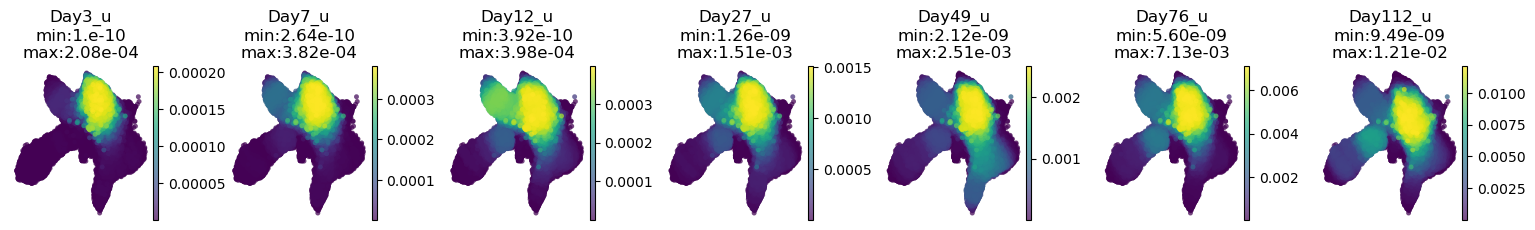

In [20]:
PINN.pl.params_in_umap(t7_ad, u_b, param='u', cell_of_t=False);

In [ ]:
cellstate = torch.from_numpy(DS_t7.cellstate).float()

In [ ]:
cellstate.min(axis=0), cellstate.max(axis=0)

(torch.return_types.min(
 values=tensor([-0.0028, -0.0024, -0.0090, -0.0085, -0.0030, -0.0073, -0.0086, -0.0055,
         -0.0033, -0.0085]),
 indices=tensor([20046, 23737, 23344, 20046,   161, 11067, 23344,   345, 25430, 11907])),
 torch.return_types.max(
 values=tensor([-0.0028,  0.0034,  0.0027,  0.0062,  0.0081,  0.0043,  0.0058,  0.0097,
          0.0165,  0.0062]),
 indices=tensor([ 3681,  3681, 20046,  3199, 11169, 23344, 20046, 20046, 14348, 25166])))

In [ ]:
adata.obsm['DM_EigenVectors'].shape

(49390, 30)

In [ ]:
t7_ad.obsm['DM_EigenVectors'].shape

(25948, 30)

# sample input

In [ ]:
subset_cb = np.random.choice(t7_ad.obs_names, int(0.2*len(t7_ad.obs_names)), replace=False)
subset_ad = t7_ad[subset_cb].copy()

In [ ]:
sampled_cbs = np.random.choice(t7_ad.obs_names, 20)
sampled_ad = t7_ad[sampled_cbs].copy()

# ODE solve

In [39]:
from torch import nn

In [90]:
device = mlp_model.device

class Diffusion_equation(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, t, y):
        
        # u = y[0]
        s = y[1]
        s.requires_grad = True
        
        t_in = torch.full((s.shape[0],1), t*15).float().to(device).requires_grad_()

        s.requires_grad = True
        t_in.requires_grad = True

        u = self.model.u(s,t_in)
        D = self.model.D(s,t_in)
        v = self.model.v(s,t_in)
        g = self.model.g(s,t_in) # d- dim

        
        
            
        diffuse = self.model.mul(D, u_ss)
        drift = self.model.mul(v, duds)
        growth = self.model.mul(g, u)

        dudt = growth + diffuse - drift

        return dudt * 1e-3, torch.zeros_like(s).float().to(device).requires_grad_()


In [91]:
ode =Diffusion_equation(mlp_model)

set up eval time list and initial condition

In [92]:
timepoints

array([  3,   7,  12,  27,  49,  76, 112, 161, 269])

In [74]:
# t_list
t_list = t7_ad.uns['pop']['t'][:n_timepoint] / 15

print(timepoints[:n_timepoint])
print(t_list)

[  3   7  12  27  49  76 112]
[0.2        0.46666667 0.8        1.8        3.26666667 5.06666667
 7.46666667]


In [87]:
s0 = subset_ad.obsm['DM_EigenVectors'][:,:n_dimension]
tompos_u0 = DS_t7.density_funs[0](s0.T)

s0 = torch.from_numpy(s0).float().to(device).requires_grad_()
tompos_u0 = torch.from_numpy(tompos_u0).float().to(device).requires_grad_()

init_condition = (tompos_u0, s0)

In [ ]:
duds = torch.autograd.grad(u.sum(), s, create_graph=True)[0]
        
# right hand side
if len(s.shape) == 1: # for one trajectory system
    
    # the second order deviritives of density u to cell state : ∂^2u/∂s^2
    #  ∂/∂s (D*∂u/∂s)
    u_ss = torch.autograd.grad(duds.sum(), s, create_graph=True)[0]

else:   # for multi-dimensiona data

    # u_ss is different for multi dimension : ∂2u / ∂s_is_i 
    u_ss_ls  = []
    for i in range(v.shape[1]):
        du_dsisi = torch.autograd.grad(duds[:,i].sum(), s, create_graph=True)[0][:, i:i+1]
        u_ss_ls.append(du_dsisi)
    u_ss = torch.cat(u_ss_ls, dim=1)

In [88]:

# configure training options
options = {}
options.update({'method': 'Dopri5'})
options.update({'h': None})
options.update({'t0': 0.2})
options.update({'t1': 7.5})
options.update({'rtol': 1e-7})
options.update({'atol': 1e-8})
options.update({'print_neval': False})
options.update({'neval_max': 1000000})
options.update({'safety': None})
options.update({'t_eval':t_list})
options.update({'interpolation_method':'cubic'})
options.update({'regenerate_graph':False})

In [89]:
u_int = odesolve(ode, init_condition, options = options) 

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [177]:
u_int = u_int.detach().cpu().numpy()

# visulize by the most correlated cells

In [178]:
from tqdm.contrib import concurrent
from scipy.stats import pearsonr

In [179]:
subset_cellstate = subset_ad.obsm['DM_EigenVectors'][:, :n_dimension]

def find_index(ode_out):
    r = [pearsonr(ode_out, dm)[0] for dm in subset_cellstate]
    indx = subset_ad.obs_names[np.argmax(r)]
    return indx

In [180]:
sout_time = np.stack([[t]*len(sampled_cbs) for t in timepoints[:n_timepoint]]).flatten()
matched_cbs = concurrent.process_map(find_index, s_int.reshape(-1,10), max_workers=20, chunksize=2)

matched_cbs = pd.DataFrame({'cb':matched_cbs, 'time':sout_time})

  0%|          | 0/140 [00:00<?, ?it/s]

In [181]:
matched_cbs.head()

,cb,time
0,16w_SITTE12_TCGTGGGAGCAAGGAA-1-10x,3
1,7w11w_SITTC3_ATTCCCGAGCACACCC-1-10x,3
2,2w4w_SITTE4_GCAGTTATCCAAGCAT-1-10x,3
3,7w11w_SITTC3_CTCACTGCAGAGGTTG-1-10x,3
4,7w11w_SITTD3_TGTACAGTCACCATGA-1-10x,3


## visualize

In [182]:
from matplotlib import cm

In [183]:
orange_colorlist = cm.get_cmap('Oranges', 7)

In [184]:
orange_colorlist(6)

(0.4980392156862745, 0.15294117647058825, 0.01568627450980392, 1.0)

In [185]:
coords_ls = []
for i,t in enumerate(timepoints[:n_timepoint]):
    cb_t = matched_cbs.query("`time` == @t").cb.tolist()

    coords_ls.append(subset_ad[cb_t].obsm['X_umap'])

coords_ls = np.stack(coords_ls) # 7, 20, 2

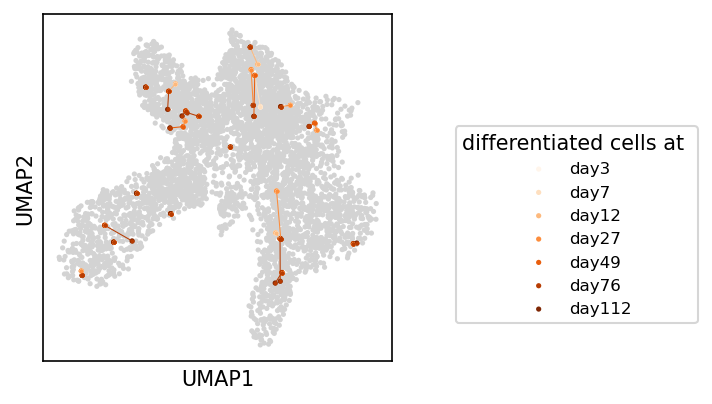

In [186]:
fig = plt.figure(figsize=(3,3), dpi=150)
ax = fig.gca()

sc.pl.umap(subset_ad, return_fig=False, show=False, ax=ax, size=25)

for t in range(6):
    for i in range(20):
        ax.plot(coords_ls[t:t+2, i, 0], coords_ls[t:t+2, i, 1], color=orange_colorlist(t), marker='o', markersize=1, linewidth=0.5)

for i,t in enumerate(timepoints[:n_timepoint]):
    cb_t = matched_cbs.query("`time` == @t").cb.tolist()

    sc.pl.umap(subset_ad[cb_t], na_color=orange_colorlist(i), return_fig=False, show=False, ax=ax, size=25, label=f'day{t}')

ax.legend(bbox_to_anchor=[0.9,0.2,1,0.5], fontsize=8, title="differentiated cells at ")

# visualize with scVelo

In [40]:
from anndata import AnnData
import scvelo as scv

In [66]:
# obs
sout_cbs = sum([[f"{cb}_t{t}" for cb in sampled_cbs] for t in timepoints[:n_timepoint]], [])
sout_time = np.stack([[t]*20 for t in timepoints[:n_timepoint]]).flatten()
sout_cbs = pd.DataFrame({'cb':sout_cbs, 'time': sout_time}).set_index("cb")

# var
var = pd.DataFrame([f'DM_{i}' for i in range(n_dimension)], columns=['Feature']).set_index("Feature")

# construct adata
sout_ad = AnnData(X = s_int.reshape(-1,10), obs=sout_cbs, var=var)
sout_ad.layers['ode_s'] = s_int.reshape(-1,10)

sout_ad

AnnData object with n_obs × n_vars = 140 × 10
    obs: 'time'
    layers: 'ode_s'

In [ ]:
sc.tl.pca(sout_ad)